In [1]:
import os
import csv
import datetime as dt
import pandas as pd

# index를 날짜로 하는 데이터프레임을 price, adj_price, divend에 대해 반환
def extract_stock_data(file_path, ticker):
    extract_datas = []

    with open(os.path.join(file_path, ticker + '.csv'), newline='') as csvfile:
        reader = csv.reader(csvfile)

        for row in reader:
            extract_datas.append(row)
        
    price_dates = list(map(dt.date.fromisoformat, extract_datas[0]))
    price_history = list(map(float, extract_datas[1]))
    adj_price_dates = list(map(dt.date.fromisoformat, extract_datas[2]))
    adj_price_history = list(map(float, extract_datas[3]))
    divend_dates = list(map(dt.date.fromisoformat, extract_datas[4]))
    divend_history = list(map(float, extract_datas[5]))

    price_df = pd.DataFrame({'date': price_dates, 'price': price_history})
    adj_price_df = pd.DataFrame({'date': adj_price_dates, 'adj_price': adj_price_history})
    divend_df = pd.DataFrame({'date': divend_dates, 'divend': divend_history})

    price_df.set_index('date', inplace=True)
    adj_price_df.set_index('date', inplace=True)
    divend_df.set_index('date', inplace=True)

    return (price_df, adj_price_df, divend_df)

def make_stock_data(file_path, tickers):
    stock_data = []

    for ticker in tickers:
        price_df, adj_price_df, divend_df = extract_stock_data(file_path, ticker)
        stock_df = pd.concat([price_df, adj_price_df, divend_df], axis=1, sort=True)
        stock_df.columns = pd.MultiIndex.from_product([[ticker], stock_df.columns])
        stock_data.append(stock_df)

    stock_data = pd.concat(stock_data, axis=1, sort=True)

    return stock_data


In [2]:
from portfolio import Portfolio

# stock 불러와서 데이터프레임화 하기
file_path = './etf'
tickers = ['QQQ', 'DGRW', 'SCHD', 'SPY', 'SCHG', 'SPYG']
stock_data = make_stock_data(file_path, tickers)
pd.options.display.float_format = '{:.2f}'.format

# test_stock = Portfolio(make_stock_data(file_path, ['QQQ', 'SCHG']), 10000)
test_stock = Portfolio(stock_data, 10000)
portfolio = Portfolio(stock_data, 10000, {"QQQ":56, "SCHD":24, "DGRW":20})

In [3]:
def calc_target_ratio(base_ratio:tuple, etc_ratio:tuple) -> tuple:
    base_sum = sum(base_ratio)
    qqq = base_ratio[0] / base_sum * 100
    etc_sum = sum(etc_ratio)
    etc1 = (etc_ratio[0] / etc_sum) * (base_ratio[1] / base_sum) * 100
    etc2 = (etc_ratio[1] / etc_sum) * (base_ratio[1] / base_sum) * 100

    return (round(qqq, 1), round(etc1, 1), round(etc2, 1))

In [72]:
from joblib import Parallel, delayed
from portfolio_test import portfolio_backtest_by_duration
from portfolio_test import make_benchmark_data

combi_stats = pd.DataFrame(columns=['cagr', 'stdev', 'mdd', 'beta', 'alpha'])
example = Portfolio(stock_data, 10000, {'QQQ':50, 'SCHD':30, 'DGRW':20 })
benchmark = Portfolio(stock_data, 10000, {'QQQ':100})
duration = 5
cash_flow = 700

benchmark_data = make_benchmark_data(benchmark, example.start_date, duration, cash_flow)

param_list = []
for qqq_weight in range(0, 100, 5):
    for schd_weight in range(0, 10):
        ratio_qqq_etc = (qqq_weight, 100 - qqq_weight)
        ratio_schd_dgrw = (schd_weight, 10 - schd_weight)
        ratio_qqq_schd_dgrw = calc_target_ratio(ratio_qqq_etc, ratio_schd_dgrw)
        
        target_ratio = {
            'QQQ': ratio_qqq_schd_dgrw[0],
            'SCHD': ratio_qqq_schd_dgrw[1],
            'DGRW': ratio_qqq_schd_dgrw[2]
        }
        print(target_ratio)
        p = Portfolio(stock_data, 10000, target_ratio)
        param_list.append((p, benchmark_data, None, duration, cash_flow))

# results = []
# for params in param_list:
#     results.append(portfolio_backtest_by_duration(*params))
with Parallel(n_jobs=-1) as parallel:
    results = parallel(delayed(portfolio_backtest_by_duration)(*params) for params in param_list)
        
for stat in results:
    combi_stats = pd.concat([combi_stats, stat])

{'QQQ': 0.0, 'SCHD': 0.0, 'DGRW': 100.0}
{'QQQ': 0.0, 'SCHD': 10.0, 'DGRW': 90.0}
{'QQQ': 0.0, 'SCHD': 20.0, 'DGRW': 80.0}
{'QQQ': 0.0, 'SCHD': 30.0, 'DGRW': 70.0}
{'QQQ': 0.0, 'SCHD': 40.0, 'DGRW': 60.0}
{'QQQ': 0.0, 'SCHD': 50.0, 'DGRW': 50.0}
{'QQQ': 0.0, 'SCHD': 60.0, 'DGRW': 40.0}
{'QQQ': 0.0, 'SCHD': 70.0, 'DGRW': 30.0}
{'QQQ': 0.0, 'SCHD': 80.0, 'DGRW': 20.0}
{'QQQ': 0.0, 'SCHD': 90.0, 'DGRW': 10.0}
{'QQQ': 5.0, 'SCHD': 0.0, 'DGRW': 95.0}
{'QQQ': 5.0, 'SCHD': 9.5, 'DGRW': 85.5}
{'QQQ': 5.0, 'SCHD': 19.0, 'DGRW': 76.0}
{'QQQ': 5.0, 'SCHD': 28.5, 'DGRW': 66.5}
{'QQQ': 5.0, 'SCHD': 38.0, 'DGRW': 57.0}
{'QQQ': 5.0, 'SCHD': 47.5, 'DGRW': 47.5}
{'QQQ': 5.0, 'SCHD': 57.0, 'DGRW': 38.0}
{'QQQ': 5.0, 'SCHD': 66.5, 'DGRW': 28.5}
{'QQQ': 5.0, 'SCHD': 76.0, 'DGRW': 19.0}
{'QQQ': 5.0, 'SCHD': 85.5, 'DGRW': 9.5}
{'QQQ': 10.0, 'SCHD': 0.0, 'DGRW': 90.0}
{'QQQ': 10.0, 'SCHD': 9.0, 'DGRW': 81.0}
{'QQQ': 10.0, 'SCHD': 18.0, 'DGRW': 72.0}
{'QQQ': 10.0, 'SCHD': 27.0, 'DGRW': 63.0}
{'QQQ': 10.0, 'SC

KeyboardInterrupt: 

In [220]:
from joblib import Parallel, delayed
from portfolio_test import portfolio_backtest_by_duration
from portfolio_test import make_benchmark_data

# buy, sell ratio를 변경해서 백테스트
buysell_ratio_stats = pd.DataFrame(columns=['cagr', 'stdev', 'mdd', 'beta', 'alpha'])
example = Portfolio(stock_data, 10000, {'QQQ':50, 'SCHD':30, 'DGRW':20 })
benchmark = Portfolio(stock_data, 10000, {'QQQ':100})
duration = 5
cash_flow = 700

benchmark_data = make_benchmark_data(benchmark, example.start_date, duration, cash_flow)


target_ratio_list = [
    { 'QQQ': 30, 'SCHD': 49, 'DGRW': 21 },
    { 'QQQ': 35, 'SCHD': 58.5, 'DGRW': 6.5 },
    # { 'QQQ': 40, 'SCHD': 48, 'DGRW': 12 },
    # { 'QQQ': 40, 'SCHD': 36, 'DGRW': 24 },
    { 'QQQ': 40, 'SCHD': 42, 'DGRW': 18 },
    { 'QQQ': 50, 'SCHD': 35, 'DGRW': 15 },
    # { 'QQQ': 50, 'SCHD': 45, 'DGRW': 5 },
    { 'QQQ': 55, 'SCHD': 40, 'DGRW': 4.5 }
]
param_list = []
for target_ratio in target_ratio_list:
    for buy_ratio in range(1, 16):
        for sell_ratio in range(1, 16):
            print(f'target_ratio: {target_ratio}, buy_ratio: {buy_ratio}, sell_ratio: {sell_ratio}')
            p = Portfolio(stock_data, 10000, target_ratio, buy_ratio=buy_ratio, sell_ratio=sell_ratio)
            param_list.append((p, benchmark_data, None, duration, cash_flow))

with Parallel(n_jobs=-1) as parallel:
    results = parallel(delayed(portfolio_backtest_by_duration)(*params) for params in param_list)

for i, stat in enumerate(results):
    p = param_list[i][0]
    stat.insert(len(stat.columns), 'b_r', p.buy_ratio)
    stat.insert(len(stat.columns), 's_r', p.sell_ratio)
    buysell_ratio_stats = pd.concat([buysell_ratio_stats, stat])

target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 1
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 2
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 3
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 4
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 5
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 6
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 7
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 8
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 9
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 10
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 11
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}, buy_ratio: 1, sell_ratio: 12
target_ratio: {'QQQ': 30, 'SCHD': 49, 'DGRW': 21}

In [ ]:
combi_stats.to_csv('./stats_qqq_schd_dgrw.csv')

In [ ]:
combi_stats.to_csv('./stats_qqq_schd_dgrw_cash_flow.csv')

In [219]:
buysell_ratio_stats.to_csv('./stats_buysell_ratio.csv')

In [221]:
buysell_ratio_stats.to_csv('./stats_buysell_ratio_cash_flow.csv')

In [ ]:
original_stats = pd.read_csv('./stats_qqq_schd_dgrw.csv', index_col=0)
cash_flow_stats = pd.read_csv('./stats_qqq_schd_dgrw_cash_flow.csv', index_col=0)
stats = original_stats.copy()
stats.insert(1, 'total_cagr', cash_flow_stats['cagr'])
stats['mdd'] = cash_flow_stats['mdd']

In [222]:
original_stats = pd.read_csv('./stats_buysell_ratio.csv', index_col=0)
cash_flow_stats = pd.read_csv('./stats_buysell_ratio_cash_flow.csv', index_col=0)
stats = original_stats.copy()
stats.insert(1, 'total_cagr', cash_flow_stats['cagr'])
stats['mdd'] = cash_flow_stats['mdd']

In [223]:
weight_map = {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0,
              5: 1.1, 6: 1.1,
              7: 1.2, 8: 1.2}

stats['weight'] = stats.index.map(lambda x: weight_map[x % 9])

def weighted_alpha_mean(group):
    d = group['alpha']
    w = group['weight']
    return (d * w).sum() / w.sum()

stats.astype({'cagr': 'float64', 'stdev': 'float64', 'mdd': 'float64', 'beta': 'float64', 'alpha': 'float64', 'ratio': 'str'})

# stat_summary_weighted_alpha = stats.groupby(['ratio']).apply(weighted_alpha_mean)
# stat_summary_mdd_quantile = stats.groupby(['ratio'])['mdd'].quantile(0.25)
stat_summary_weighted_alpha = stats.groupby(['ratio', 'b_r', 's_r']).apply(weighted_alpha_mean)
stat_summary_mdd_quantile = stats.groupby(['ratio', 'b_r', 's_r'])['mdd'].quantile(0.25)

In [224]:
# stat_summary = stats.groupby(['ratio']).mean()
stat_summary = stats.groupby(['ratio', 'b_r', 's_r']).mean()
stat_summary['alpha'] = stat_summary_weighted_alpha
stat_summary.insert(4, 'mdd_quantile', stat_summary_mdd_quantile)
stat_summary.insert(5, 'mdd_diff', stat_summary['mdd'] - stat_summary['mdd_quantile'])
stat_summary.insert(6, 'mdd_score', (stat_summary['mdd_diff'].rank(pct=True) * 0.75 + 0.25) * ((1 -stat_summary['mdd'].rank(pct=True)) * 0.25 + 0.75))
stat_summary.insert(2, 'cagr_score', stat_summary['total_cagr'] / stat_summary['cagr'])

In [275]:
stat_summary

cagr  total_cagr  cagr_score  stdev   mdd  \
ratio          b_r   s_r                                                
30.0:49.0:21.0 1.00  1.00  14.16       94.82        6.69  17.18 21.58   
                     2.00  14.19       94.85        6.68  17.22 21.58   
                     3.00  14.23       94.86        6.66  17.24 21.62   
                     4.00  14.28       94.84        6.64  17.28 21.66   
                     5.00  14.28       94.86        6.64  17.31 21.66   
                     6.00  14.29       94.88        6.64  17.36 21.66   
                     7.00  14.33       94.90        6.62  17.39 21.66   
                     8.00  14.42       94.91        6.58  17.42 21.66   
                     9.00  14.42       94.91        6.58  17.44 21.66   
                     10.00 14.45       94.92        6.57  17.49 21.66   
                     11.00 14.44       94.92        6.57  17.51 21.66   
                     12.00 14.43       94.93        6.58  17.55 21.66   
                     13.00 14.41       94.94        6.59  17.59 21.66   
                     14.00 14.42       94.94        6.59  17.64 21.66   
                     15.00 14.45       94.95        6.57  17.68 21.66   
               2.00  1.00  14.12       94.78        6.71  17.12 21.45   
                     2.00  14.13       94.79        6.71  17.16 21.48   
                     3.00  14.18       94.81        6.68  17.19 21.49   
                     4.00  14.22       94.78        6.67  17.22 21.55   
                     5.00  14.24       94.79        6.66  17.27 21.55   
                     6.00  14.21       94.82        6.67  17.31 21.55   
                     7.00  14.30       94.83        6.63  17.34 21.55   
                     8.00  14.35       94.84        6.61  17.37 21.55   
                     9.00  14.40       94.85        6.59  17.39 21.55   
                     10.00 14.40       94.86        6.59  17.43 21.55   
                     11.00 14.38       94.86        6.60  17.46 21.55   
                     12.00 14.37       94.86        6.60  17.49 21.55   
                     13.00 14.37       94.86        6.60  17.54 21.55   
                     14.00 14.37       94.88        6.60  17.58 21.55   
                     15.00 14.45       94.88        6.57  17.64 21.55   
               3.00  1.00  14.02       94.72        6.76  17.06 21.34   
                     2.00  14.08       94.73        6.73  17.09 21.33   
                     3.00  14.09       94.75        6.72  17.12 21.35   
                     4.00  14.16       94.74        6.69  17.16 21.40   
                     5.00  14.18       94.75        6.68  17.18 21.40   
                     6.00  14.19       94.79        6.68  17.22 21.40   
                     7.00  14.22       94.80        6.67  17.24 21.40   
                     8.00  14.29       94.80        6.64  17.27 21.40   
                     9.00  14.28       94.81        6.64  17.33 21.40   
                     10.00 14.32       94.82        6.62  17.33 21.40   
                     11.00 14.28       94.82        6.64  17.39 21.40   
                     12.00 14.26       94.82        6.65  17.44 21.40   
                     13.00 14.25       94.83        6.65  17.48 21.40   
                     14.00 14.32       94.84        6.62  17.48 21.40   
                     15.00 14.40       94.84        6.59  17.51 21.40   
               4.00  1.00  14.02       94.64        6.75  16.97 21.23   
                     2.00  13.99       94.64        6.76  17.04 21.25   
                     3.00  14.04       94.64        6.74  17.07 21.31   
                     4.00  14.09       94.66        6.72  17.11 21.29   
                     5.00  14.16       94.65        6.68  17.14 21.30   
                     6.00  14.17       94.65        6.68  17.18 21.30   
                     7.00  14.21       94.66        6.66  17.21 21.32   
                     8.00  14.23       94.69        6.65  17.24 21.32   
             

In [281]:
# stat_summary_sorted = stat_summary[(stat_summary['alpha'] > 0.2) & (stat_summary['total_cagr'] > 94) & (stat_summary['cagr'] > 14.5) & (stat_summary['mdd_score'] > 0.45)]
stat_summary_sorted = stat_summary.loc[:, [9, 10], :]
stat_summary_sorted = stat_summary_sorted.sort_values(by=['mdd_quantile'], ascending=True)

In [282]:
stat_summary_sorted

cagr  total_cagr  cagr_score  stdev   mdd  \
ratio          b_r   s_r                                                
30.0:49.0:21.0 10.00 1.00  13.73       94.28        6.87  16.63 20.60   
                     2.00  13.76       94.26        6.85  16.66 20.67   
               9.00  6.00  13.94       94.31        6.77  16.84 20.76   
                     4.00  13.86       94.33        6.81  16.79 20.76   
                     8.00  13.91       94.30        6.78  16.88 20.76   
                     11.00 14.00       94.30        6.73  16.99 20.76   
                     9.00  13.95       94.30        6.76  16.88 20.76   
                     7.00  13.92       94.30        6.77  16.87 20.76   
                     12.00 14.06       94.30        6.71  17.03 20.76   
                     13.00 14.07       94.30        6.70  17.06 20.76   
                     14.00 14.08       94.30        6.70  17.05 20.76   
                     10.00 13.96       94.30        6.75  16.96 20.76   
                     15.00 14.13       94.30        6.67  17.08 20.76   
                     5.00  13.88       94.33        6.79  16.81 20.76   
                     3.00  13.84       94.35        6.82  16.74 20.78   
               10.00 3.00  13.80       94.30        6.83  16.70 20.72   
                     10.00 13.94       94.36        6.77  16.94 20.71   
                     11.00 13.96       94.36        6.76  16.97 20.71   
                     4.00  13.84       94.29        6.81  16.72 20.72   
                     5.00  13.89       94.27        6.79  16.77 20.72   
                     6.00  13.93       94.36        6.77  16.80 20.69   
                     7.00  13.90       94.36        6.79  16.82 20.69   
                     8.00  13.90       94.35        6.79  16.88 20.71   
                     9.00  13.93       94.35        6.78  16.89 20.71   
                     14.00 14.01       94.39        6.74  17.02 20.71   
                     15.00 14.04       94.39        6.72  17.06 20.71   
                     12.00 14.00       94.36        6.74  16.99 20.71   
                     13.00 13.98       94.36        6.75  17.04 20.71   
               9.00  1.00  13.76       94.29        6.85  16.69 20.73   
                     2.00  13.77       94.29        6.85  16.71 20.74   
35.0:58.5:06.5 10.00 10.00 14.17       94.54        6.67  17.17 20.88   
                     3.00  14.04       94.45        6.73  16.92 20.88   
                     11.00 14.25       94.54        6.63  17.23 20.88   
                     6.00  14.05       94.54        6.73  17.02 20.86   
                     9.00  14.13       94.52        6.69  17.11 20.88   
                     8.00  14.07       94.52        6.72  17.09 20.88   
                     15.00 14.38       94.57        6.58  17.31 20.88   
                     14.00 14.34       94.57        6.60  17.28 20.88   
                     13.00 14.18       94.54        6.67  17.28 20.88   
                     12.00 14.21       94.54        6.65  17.24 20.88   
                     7.00  14.08       94.54        6.71  17.05 20.86   
                     4.00  14.05       94.43        6.72  16.97 20.87   
                     5.00  14.06       94.49        6.72  17.00 20.86   
               9.00  11.00 14.30       94.65        6.62  17.25 20.71   
                     7.00  14.16       94.64        6.69  17.08 20.71   
                     6.00  14.19       94.63        6.67  17.03 20.71   
                     8.00  14.16       94.65        6.69  17.11 20.71   
                     9.00  14.18       94.65        6.68  17.11 20.71   
                     15.00 14.33       94.65        6.60  17.34 20.71   
                     12.00 14.29       94.65        6.63  17.28 20.71   
                     13.00 14.35       94.65        6.60  17.30 20.71   
                     10.00 14.25       94.65        6.64  17.20 20.71   
                     14.00 14.37       94.65        6.59  17.27 20.71   
             

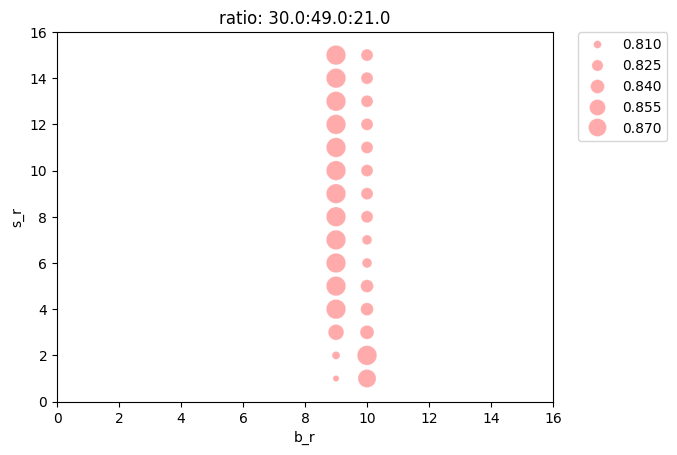

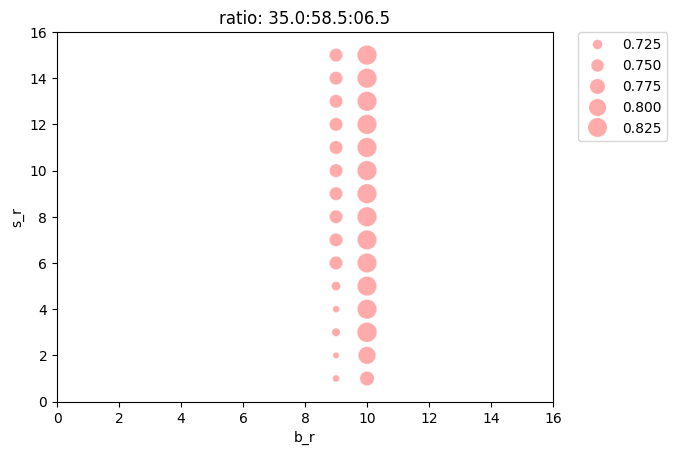

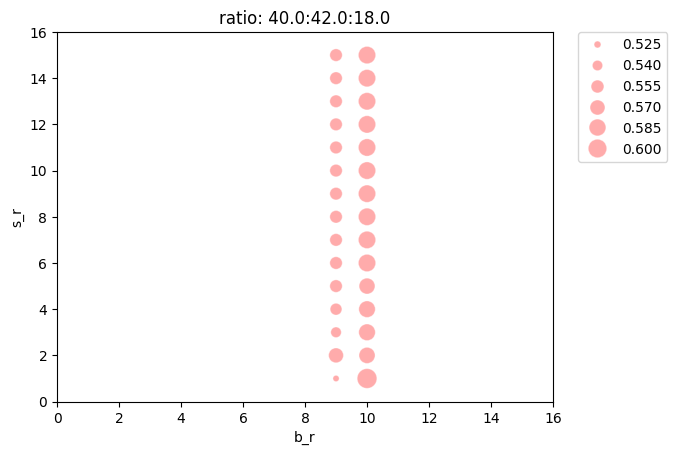

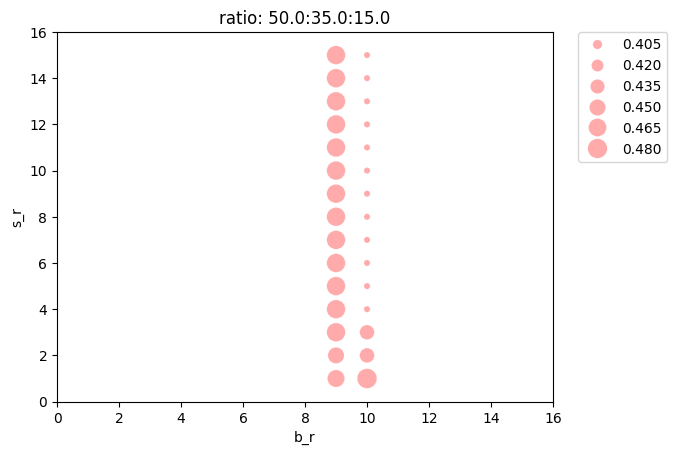

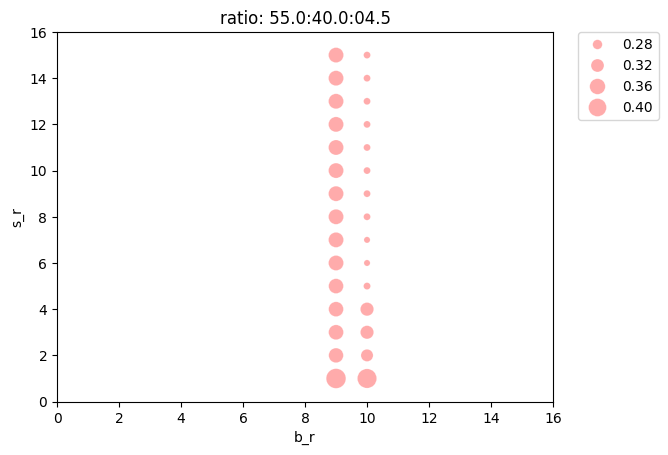

In [288]:
import seaborn as sns
import matplotlib.pyplot as plt

# filtered_stat_summary = stat_summary
filtered_stat_summary = stat_summary_sorted

for ratio in filtered_stat_summary.index.get_level_values('ratio').unique():
    subset = filtered_stat_summary.xs(ratio, level='ratio')

    fig, ax = plt.subplots()
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 16)
    # plot = sns.relplot(data=subset, x='b_r', y='s_r', size='alpha', sizes=(20, 200))
    # sns.scatterplot(data=subset, x='b_r', y='s_r', size='total_cagr', sizes=(20, 200), ax=ax)
    # sns.scatterplot(data=subset, x='b_r', y='s_r', size='cagr', sizes=(20, 200), ax=ax, color='green', alpha=0.33)
    sns.scatterplot(data=subset, x='b_r', y='s_r', size='mdd_score', sizes=(20, 200), ax=ax, color='red', alpha=0.33)
    # plot.sns.relplot(data=subset, x='b_r', y='s_r', size='mdd_score', sizes=(20, 200))
    # plot.set(title=f'ratio: {ratio}')
    plt.title(f'ratio: {ratio}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
    plt.show()